# Consensus under self-symmetric resolution-8 rules on small-world networks

This is a companion to `consensus_r9.ipynb`, with the same networks, initial states and majority baseline, but resolution $r = 8$.

**Why $r = 8$.**
- For even $r$, a cell edge lies exactly at $\rho = 1/2$, so a rule can tell a slight majority from a slight minority.
- At $r = 9$ the closed central cell $[4/9, 5/9]$ lumps the two together. A degree-9 node with 4 living neighbours sees the same cell as one with 5, so no $r = 9$ rule is exactly the majority rule.
- Does that edge help the rules reach consensus?

**Setup.**

| | |
|---|---|
| rules | the 128 self-symmetric rules of resolution $r = 8$ that keep $\rho = 0$ at $\rho = 0$, in both even-$r$ conventions (`+-` and `-+`), plus Watts' majority rule |
| networks | the same 100 Watts–Strogatz networks: $N = 1000$, ring with $k = 8$ neighbours, rewiring $p = 0.05$ |
| initial states | the same: exactly 500 living nodes; one configuration per network, shared by every rule |
| measured | first timestep $t_c$ at which all nodes agree, up to $T_\text{max} = 10^5$ (also reported at $10^4$); for a run without consensus, a cycle that proves it never gets there, if one is found |

That is 19,300 runs (the 192 distinct rules of section 1, and majority), about 2 minutes on an Apple M4. Run with the `fast-llna` environment after `pip install -e ".[notebook]"`.

For resolutions 5 to 10 across the rewiring probability $p$, see `consensus_sweep.ipynb`.

In [1]:
import time

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import Markdown, display

import fast_llna as fl

R_RES = 8  # resolution r of the density partition (even)
EVEN = ("+-", "-+")  # even-r conventions: which partition, R+ or R-, dead and living nodes use
N_NODES = 1000  # nodes per network
K, P = 8, 0.05  # Watts-Strogatz: ring with K neighbours per node, rewiring probability P
SAMPLES = 100  # (network, initial configuration) pairs, shared by all rules
T_MAX = 100_000  # runs without consensus by T_MAX are censored
T_EARLY = 10_000  # earlier horizon, also reported
SEED_INIT, SEED_MAJORITY = 1, 2  # network s is generated with seed s (as in consensus_r9)

print("backends available:", fl.available_backends())

backends available: ['metal', 'cpu', 'reference']


## 1. Even resolution and the self-symmetric rules

**The cells.** For $r = 8$ the cells below $1/2$ are $R_0 = [0, \tfrac18[$, …, $R_3 = [\tfrac38, \tfrac12[$, and the cells above are their mirror images $R_4 = ]\tfrac12, \tfrac58]$, …, $R_7 = ]\tfrac78, 1]$.

**The tie.** The point $\rho = 1/2$ is the shared edge of $R_3$ and $R_4$. Putting it in either cell for every node would break complementation symmetry. The thesis (App. symmetry) restores the symmetry with two partitions: $R^+$ puts $\rho = 1/2$ in $R_3$ and $R^-$ puts it in $R_4$. Dead and living nodes use different ones:

| convention | dead nodes (born set $B$) | living nodes (survive set $S$) | a tied dead node reads | a tied living node reads |
|---|---|---|---|---|
| `+-` (thesis default) | $R^+$ | $R^-$ | $\beta_3$ | $\sigma_4$ |
| `-+` | $R^-$ | $R^+$ | $\beta_4$ | $\sigma_3$ |

Away from the tie both conventions read the same cells.

**Self-symmetric rules.** Within one convention the equivalence map is the same as for odd $r$, so again a rule is self-symmetric exactly when
$$\sigma = 2^r - 1 - \overline{\beta}.$$
That gives $2^8 = 256$ self-symmetric rules per convention, out of $4^8 = 65\,536$.

**Keeping $\rho = 0$ at $\rho = 0$.** We keep only rules in which a dead node with no living neighbours stays dead: $\beta_0 = 0$.
- For a self-symmetric rule, $\sigma_7 = 1 - \beta_0$. A kept rule therefore also keeps $\rho = 1$ at $\rho = 1$: both uniform states are fixed points, and consensus, once reached, stays put.
- The dropped half ($\beta_0 = 1$) turns all-dead into all-alive and back, forever.
- Dropping them loses no information. Each dropped rule is the output complement $(2^r-1-\beta,\ 2^r-1-\sigma)$ of a kept one, and for self-symmetric $\Phi$ we have $\neg\Phi(\neg\Phi(x)) = \Phi(\Phi(x))$. Its trajectory is therefore the kept rule's with every odd timestep complemented, and it reaches the uniform states at exactly the same timesteps.

That leaves $2^{r-1} = 128$ rules per convention.

**The two conventions overlap.**
- For a self-symmetric rule, $\sigma_3 = 1 - \beta_4$ and $\sigma_4 = 1 - \beta_3$.
- So if $\beta_3 = \beta_4$, a tie reads the same bits in both conventions and the two versions are the same rule. That holds for 64 of the 128 kept rules.
- The other 64 rules, with $\beta_3 \ne \beta_4$, come in two different versions, for 192 distinct rules in total.
- A check in section 4 confirms this on the degrees of our networks. Each distinct rule is simulated once: all 128 under `+-`, and the 64 unshared ones under `-+`.

In [2]:
FULL = 2**R_RES - 1
LO, HI = R_RES // 2 - 1, R_RES // 2  # the two cells that meet at rho = 1/2


def mirror(v):
    """Reverse the R_RES bits of v: cell j <-> cell R_RES - 1 - j."""
    return int(f"{v:0{R_RES}b}"[::-1], 2)


codes = fl.self_equivalent(R_RES)  # int64 [2^r, 2]: (beta, sigma), sorted by beta; the same in either convention
assert len(codes) == 2**R_RES
assert np.array_equal(np.stack(fl.equivalent(R_RES, *codes.T), axis=1), codes)  # each is its own equivalent
assert all(s == FULL - mirror(b) for b, s in codes)

kept = codes[codes[:, 0] % 2 == 0]  # beta_0 = 0: rho = 0 stays rho = 0
dropped = codes[codes[:, 0] % 2 == 1]
assert np.array_equal(codes[:, 1] >> (R_RES - 1), 1 - codes[:, 0] % 2)  # sigma_7 = 1 - beta_0
assert {tuple(c) for c in FULL - dropped} == {tuple(c) for c in kept}  # the dropped are output complements of the kept
beta, sigma = kept.T

rules = {c: fl.life_like(R_RES, beta, sigma, partition=fl.symmetric(R_RES, c)) for c in EVEN}
shared = ((beta >> LO) & 1) == ((beta >> HI) & 1)  # a tie reads the same bits in both conventions
print(f"{len(codes)} self-symmetric rules per convention out of {4**R_RES:,}; {len(beta)} keep rho = 0 at "
      f"rho = 0, of which {shared.sum()} are the same in both conventions")

256 self-symmetric rules per convention out of 65,536; 128 keep rho = 0 at rho = 0, of which 64 are the same in both conventions


## 2. The threshold rule and its two exact relatives

Watts' majority rule makes a node alive if $\rho > 1/2$, dead if $\rho < 1/2$, and flips a fair coin at $\rho = 1/2$. It runs on its own partition `fl.MAJORITY`.

**Two exact relatives.** At $r = 8$ the majority rule has two exact deterministic relatives among the self-symmetric rules. Both are $\phi^8_{240,240}$, with $B = S = \{R_4, \dots, R_7\}$: away from a tie, a node is alive iff $\rho > 1/2$. They differ only at the tie:
- under `+-`, a tied dead node reads $\beta_3 = 0$ and stays dead, and a tied living node reads $\sigma_4 = 1$ and stays alive. This is **majority, keep the state on a tie**.
- under `-+`, a tied dead node reads $\beta_4 = 1$ and is born, and a tied living node reads $\sigma_3 = 0$ and dies. This is **majority, flip the state on a tie**.

**Where the coin sits.** For a tied node in state $s$, keep-on-tie gives next state $s$ and flip-on-tie gives $1 - s$. Watts' coin makes it alive with probability $\tfrac12 = \tfrac12[s + (1 - s)]$, so per tied node its expected next state is the average of the two. Unlike the $r = 9$ relative $\phi^9_{480,496}$, both are exact at every degree.

In the diagrams below, black means alive at the next step, and the red line marks the edge at $\rho = 1/2$.

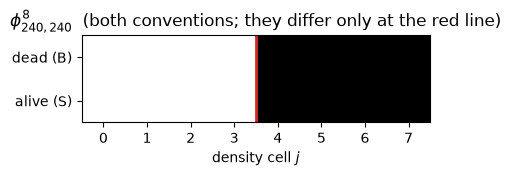

In [3]:
def show_rule(ax, b, s, convention):
    """Response diagram: next state (black = alive) per density cell, for dead (B) and living (S) nodes."""
    cells = np.arange(R_RES)
    ax.imshow([(b >> cells) & 1, (s >> cells) & 1], cmap="Greys", vmin=0, vmax=1)
    ax.axvline(LO + 0.5, color="tab:red", lw=2)  # rho = 1/2
    ax.set(xticks=cells, yticks=[0, 1], yticklabels=["dead (B)", "alive (S)"], xlabel="density cell $j$")
    ax.set_title(rf"$\phi^{{{R_RES}}}_{{{b},{s}}}$  ({convention})")


assert FULL - mirror(240) == 240
fig, ax = plt.subplots(figsize=(4.5, 1.6))
show_rule(ax, 240, 240, "both conventions; they differ only at the red line")
plt.show()

## 3. Networks and initial states

The networks and initial states are the same as in `consensus_r9.ipynb` (same seeds), so results pair run by run across the two notebooks:
- 100 networks from `networkx.connected_watts_strogatz_graph(1000, 8, 0.05, seed=s)`, joined into one graph with `fl.union`;
- one configuration per network with exactly 500 living nodes, shared by every rule.

In [4]:
nets = [
    fl.Graph(nx.to_scipy_sparse_array(nx.connected_watts_strogatz_graph(N_NODES, K, P, seed=s)))
    for s in range(SAMPLES)
]
graph, offsets = fl.union(*nets)  # network s is nodes offsets[s] .. offsets[s + 1] - 1
x0 = fl.random_states(N_NODES, SAMPLES, seed=SEED_INIT).to_bool()  # [SAMPLES, N_NODES], 500 alive each

deg = graph.degree
print(f"union: {graph.n:,} nodes; degree {deg.min()}..{deg.max()}, mean {deg.mean():.2f}; "
      f"{np.mean(deg % 2 == 0):.0%} of nodes have even degree (ties possible)")

union: 100,000 nodes; degree 4..12, mean 8.00; 72% of nodes have even degree (ties possible)


## 4. Consensus detection

`fl.consensus` detects consensus and cycles as described in `consensus_r9.ipynb`:
- **Consensus**: all 1000 nodes of a network share one state. It is absorbing, so $t_c$ is the first such timestep.
- **Cycle**: a deterministic run whose configuration repeats without consensus can never reach consensus. Each run keeps a reference configuration, replaced at every power of two ($t = 1, 2, 4, \dots$), and every frame is compared with it; the first return gives the exact minimal period. At $T_\text{max} = 10^5$ this finds every cycle entered by $t = 65\,536$ with a period of at most $34\,464$; a cycle entered later, or with a longer period, is not found.
- **Open**: neither consensus nor a cycle found by $T_\text{max}$. Majority is stochastic, so its runs reach consensus or stay open.

**Self-checks.**
1. Every rule really is self-symmetric in its convention: started from the complemented configurations, it produces the complemented trajectory, $\Phi(\neg x) = \neg\Phi(x)$.
2. On the degrees of these networks, a shared rule has the same exact table in both conventions (next state for every degree $k$ and number $q \le k$ of living neighbours, from `Rules.exact`), so the two versions are the same function; every unshared rule's two versions differ.

In [5]:
x = np.broadcast_to(x0.ravel(), (len(beta), graph.n))
for conv in EVEN:
    traj = fl.simulate(graph, rules[conv], x, 5).states.to_bool()
    assert np.array_equal(traj, ~fl.simulate(graph, rules[conv], ~x, 5).states.to_bool()), conv
del traj

ks = np.unique(graph.degree)
same = np.all(rules["+-"].exact(ks).p == rules["-+"].exact(ks).p, axis=(1, 2))  # same function on these degrees
assert np.array_equal(same, shared)
print("all rules commute with complementation; on these degrees a rule is the same in both conventions iff shared")

all rules commute with complementation; on these degrees a rule is the same in both conventions iff shared


## 5. Simulation

As in the companion notebook, with one `fl.consensus` call per convention (the 128 rules under `+-`, the 64 unshared ones under `-+`) and one for majority.

The majority run is identical to the one in `consensus_r9.ipynb`: same graph, same seed.

In [6]:
cons = {}
for conv, keep in (("+-", np.ones_like(shared)), ("-+", ~shared)):
    start = time.perf_counter()
    cons[conv] = fl.consensus(graph, rules[conv].take(np.flatnonzero(keep)), x0.ravel(), T_MAX, offsets=offsets)
    print(f"convention {conv}: {keep.sum()} rules x {SAMPLES} networks to t = {T_MAX:,}: {time.perf_counter() - start:.0f} s")

start = time.perf_counter()
c_maj = fl.consensus(graph, fl.majority(0.5), x0.ravel(), T_MAX, offsets=offsets, seed=SEED_MAJORITY)
t_maj = c_maj.t_consensus[:, 0]
print(f"majority x {SAMPLES} networks to t = {T_MAX:,}: {time.perf_counter() - start:.0f} s")

convention +-: 128 rules x 100 networks to t = 100,000: 54 s


convention -+: 64 rules x 100 networks to t = 100,000: 52 s


majority x 100 networks to t = 100,000: 13 s


## 6. Results

### Overview

The table below counts the **192 distinct rules**, split into the 64 shared ones and the two versions of the other 64. The classes are as in the companion notebook:
- **always**: all 100 runs reach consensus;
- **sometimes**: some runs reach consensus;
- **never: every run cycles**: every run entered a cycle (of any period) without consensus, which proves that none of these 100 runs ever reaches consensus;
- **never within $T_\text{max}$: some runs open**: no run reached consensus, and some are open at $T_\text{max}$.

In [7]:
# the 192 distinct rules: every "+-" rule, plus the "-+" version of each unshared one
b_d, s_d = np.r_[beta, beta[~shared]], np.r_[sigma, sigma[~shared]]
conv_d = np.r_[np.where(shared, "both", "+-"), np.full((~shared).sum(), "-+")]
t_d, cyc_d, period_d = (np.c_[getattr(cons["+-"], f), getattr(cons["-+"], f)] for f in ("t_consensus", "t_cycle", "period"))

reached, cycled = np.isfinite(t_d), np.isfinite(cyc_d)  # [sample, distinct rule]
n_hit, n_cyc = reached.sum(0), cycled.sum(0)
n_open = SAMPLES - n_hit - n_cyc  # neither consensus nor a cycle by T_MAX
classes = {
    "always consensus": n_hit == SAMPLES,
    "sometimes consensus": (n_hit > 0) & (n_hit < SAMPLES),
    "never: every run cycles": n_cyc == SAMPLES,
    "never within T_MAX: some runs open": (n_hit == 0) & (n_open > 0),
}
groups = {"shared (both)": conv_d == "both", "`+-` version": conv_d == "+-", "`-+` version": conv_d == "-+"}
lines = ["| rules | " + " | ".join(groups) + " | all distinct |", "|---" * (len(groups) + 2) + "|"]
for name, member in classes.items():
    lines.append(f"| {name} | " + " | ".join(str((member & g).sum()) for g in groups.values()) + f" | {member.sum()} |")
display(Markdown("\n".join(lines)))
print(f"runs (distinct rules): {reached.sum():,} consensus, {cycled.sum():,} cycle without consensus, "
      f"{n_open.sum():,} open at T_MAX (of {reached.size:,})")
period, t_ref = period_d[cycled], (cyc_d - period_d)[cycled]  # the cycle was entered by t_ref
print(f"cycle periods: 1 (frozen) in {np.mean(period == 1):.1%} of cycling runs, 2 in {np.mean(period == 2):.1%}; "
      f"median {np.median(period):.0f}, max {period.max():,}")
late = 2 ** np.arange(12, 17)  # references at t = 4,096 .. 65,536
print("cycles by the reference that found them: " + ", ".join(f"{np.sum(t_ref == t):,} at t = {t:,}" for t in late)
      + f"; {np.sum(t_ref < late[0]):,} before")
print(f"runs in consensus by t = {T_EARLY:,}: {(t_d <= T_EARLY).sum():,}")
print(f"majority: {np.isfinite(t_maj).sum()} of {SAMPLES} runs reach consensus ({(t_maj <= T_EARLY).sum()} by {T_EARLY:,})")
for conv in EVEN:  # the exact majority relatives phi_240,240: keep (+-) or flip (-+) on a tie
    i = np.flatnonzero((b_d == 240) & (conv_d == conv))[0]
    print(f"phi_240,240 {conv}: {n_cyc[i]} of {SAMPLES} runs cycle; period "
          + ", ".join(f"{v} in {n}" for v, n in zip(*np.unique(period_d[cycled[:, i], i], return_counts=True), strict=True))
          + f" runs; every cycle entered by t = {(cyc_d - period_d)[cycled[:, i], i].max():,.0f}")

| rules | shared (both) | `+-` version | `-+` version | all distinct |
|---|---|---|---|---|
| always consensus | 0 | 0 | 0 | 0 |
| sometimes consensus | 0 | 2 | 0 | 2 |
| never: every run cycles | 47 | 17 | 24 | 88 |
| never within T_MAX: some runs open | 17 | 45 | 40 | 102 |

runs (distinct rules): 69 consensus, 9,250 cycle without consensus, 9,881 open at T_MAX (of 19,200)
cycle periods: 1 (frozen) in 17.7% of cycling runs, 2 in 38.0%; median 2, max 7,752
cycles by the reference that found them: 153 at t = 4,096, 63 at t = 8,192, 47 at t = 16,384, 53 at t = 32,768, 56 at t = 65,536; 8,878 before
runs in consensus by t = 10,000: 29
majority: 0 of 100 runs reach consensus (0 by 10,000)
phi_240,240 +-: 100 of 100 runs cycle; period 1 in 27, 2 in 73 runs; every cycle entered by t = 16
phi_240,240 -+: 100 of 100 runs cycle; period 2 in 100 runs; every cycle entered by t = 32


### Rules that reach consensus

Columns:
- **runs by $10^4$ / $10^5$**: how many of the 100 networks reach consensus by each horizon.
- **cycle / open**: of the other networks, how many end in a cycle (so never reach consensus) and how many are open at $T_\text{max}$.
- **$t_c$ where reached**: min / median / max over the runs that do reach consensus by $T_\text{max}$.
- **vs majority**: on the same network and initial state, how often the rule is faster (wins) or slower (losses); a run without consensus by $T_\text{max}$ counts as $t_c = \infty$. Here majority never reaches consensus, so the wins are just the rule's consensus count and there are no losses; no test is needed.

"both" marks a rule that is the same in both conventions.

In [8]:
def name(i):
    return rf"$\phi^8_{{{b_d[i]},{s_d[i]}}}$"


def row(label, t, t_cycle, versus_majority=True):
    done, n_cyc = t[np.isfinite(t)], int(np.isfinite(t_cycle).sum())
    span = " / ".join(f"{v:.0f}" for v in (done.min(), np.median(done), done.max())) if done.size else "-"
    cells = [label, str((done <= T_EARLY).sum()), str(done.size), f"{n_cyc} / {SAMPLES - done.size - n_cyc}", span, ""]
    if versus_majority:
        cells[5] = f"{int((t < t_maj).sum())} / {int((t > t_maj).sum())}"
    return "| " + " | ".join(cells) + " |"


lead = list(np.flatnonzero(n_hit))
lead.sort(key=lambda i: (-n_hit[i], np.median(t_d[:, i])))
lines = ["| rule | convention | runs by $10^4$ | runs by $10^5$ | cycle / open | $t_c$ where reached "
         "| vs majority: wins / losses |", "|---|---|---|---|---|---|---|"]
lines += [row(f"{name(i)} | `{conv_d[i]}`", t_d[:, i], cyc_d[:, i]) for i in lead]
lines.append(row("Watts majority, coin at $\\rho = 1/2$ | ", t_maj, c_maj.t_cycle[:, 0], versus_majority=False))
display(Markdown("\n".join(lines)))
for i in lead:  # the other version of each unshared rule in the table
    if conv_d[i] != "both":
        j = np.flatnonzero((b_d == b_d[i]) & (conv_d != conv_d[i]))[0]
        print(f"{name(j)} `{conv_d[j]}`: {n_hit[j]} consensus, {n_cyc[j]} cycle, {n_open[j]} open")

| rule | convention | runs by $10^4$ | runs by $10^5$ | cycle / open | $t_c$ where reached | vs majority: wins / losses |
|---|---|---|---|---|---|---|
| $\phi^8_{244,208}$ | `+-` | 28 | 68 | 18 / 14 | 1468 / 15298 / 87960 | 68 / 0 |
| $\phi^8_{200,236}$ | `+-` | 1 | 1 | 99 / 0 | 205 / 205 / 205 | 1 / 0 |
| Watts majority, coin at $\rho = 1/2$ |  | 0 | 0 | 0 / 100 | - |  |

$\phi^8_{244,208}$ `-+`: 0 consensus, 100 cycle, 0 open
$\phi^8_{200,236}$ `-+`: 0 consensus, 62 cycle, 38 open


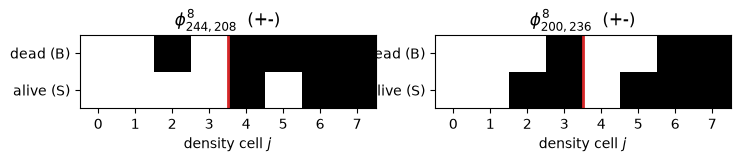

In [9]:
top = lead[:8]
if top:
    fig, axes = plt.subplots(1, len(top), figsize=(4.2 * len(top), 1.6), squeeze=False)
    for ax, i in zip(axes[0], top, strict=True):
        show_rule(ax, b_d[i], s_d[i], conv_d[i])
    plt.show()

### Time to consensus

Each curve is the fraction of the 100 runs that are in consensus by timestep $t$ (the eight fastest rules and majority). Its height at $T_\text{max}$ is the fraction that reached consensus at all; the dotted line marks $10^4$.

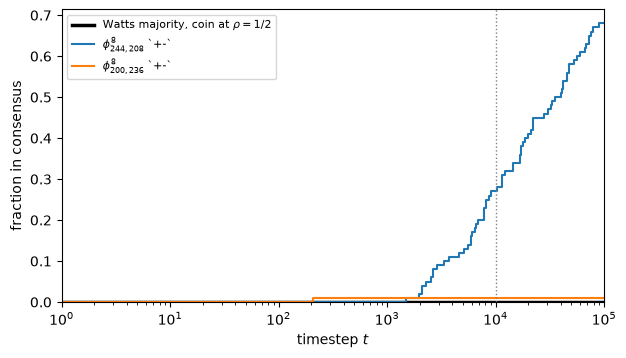

In [10]:
t_grid = np.unique(np.geomspace(1, T_MAX, 400).astype(int))


def reached_by(t):
    return (t[:, None] <= t_grid).mean(axis=0)


fig, ax = plt.subplots(figsize=(7, 3.8))
ax.step(t_grid, reached_by(t_maj), where="post", color="k", lw=2.5, label=r"Watts majority, coin at $\rho = 1/2$")
for i in top:
    ax.step(t_grid, reached_by(t_d[:, i]), where="post", label=f"{name(i)} `{conv_d[i]}`")
ax.axvline(T_EARLY, color="grey", ls=":", lw=1)
ax.set(xscale="log", xlim=(1, T_MAX), ylim=(0, None), xlabel="timestep $t$", ylabel="fraction in consensus")
ax.legend(loc="upper left", fontsize=8)
plt.show()

### What the runs look like

The space-time diagrams below use one network: the first that the most successful rule (the first row of the table) brings to consensus, or network 0 if no rule does. They show:
- Watts' majority;
- its two exact relatives: keep the state on a tie, and flip it on a tie;
- that most successful rule.

Nodes run left to right in ring order, time runs downward, and black means alive.

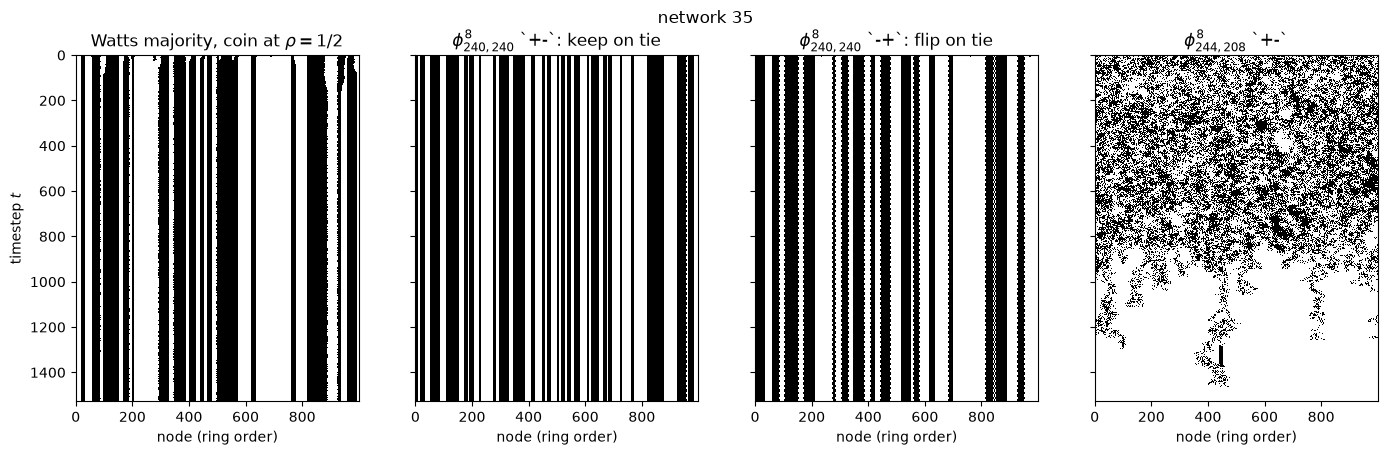

In [11]:
best = lead[0] if lead else None
s = int(np.argmin(t_d[:, best])) if best is not None else 0
t_show = int(min(10_000, t_d[s, best] + 60)) if best is not None else 300
# majority: the union run of section 5 (same seed, same node indices), cut to network s (one bit per node)
maj = fl.simulate(graph, fl.majority(0.5), x0.reshape(1, -1), t_show, seed=SEED_MAJORITY).states.bits
cut = slice(s * N_NODES // 8, (s + 1) * N_NODES // 8)  # needs N_NODES % 8 == 0


def spacetime(rule):
    """Network s on its own: a deterministic rule evolves exactly as inside the union."""
    return fl.simulate(nets[s], rule, x0[s : s + 1], t_show).states.to_bool()[:, 0]


def life_like(b, convention):
    return rules["+-" if convention == "both" else convention].take(int(np.searchsorted(beta, b)))


panels = [
    (r"Watts majority, coin at $\rho = 1/2$", fl.States(maj[:, cut], 1, N_NODES).to_bool()[:, 0]),
    (r"$\phi^8_{240,240}$ `+-`: keep on tie", spacetime(life_like(240, "+-"))),
    (r"$\phi^8_{240,240}$ `-+`: flip on tie", spacetime(life_like(240, "-+"))),
]
if best is not None:
    panels.append((rf"$\phi^8_{{{b_d[best]},{s_d[best]}}}$ `{conv_d[best]}`", spacetime(life_like(b_d[best], conv_d[best]))))

fig, axes = plt.subplots(1, len(panels), figsize=(4.2 * len(panels), 4.5), sharey=True)
for ax, (title, x) in zip(axes, panels, strict=True):
    ax.imshow(x, cmap="Greys", aspect="auto", interpolation="nearest")
    ax.set(title=title, xlabel="node (ring order)")
axes[0].set_ylabel("timestep $t$")
fig.suptitle(f"network {s}")
plt.show()

## 7. Conclusions

These hold for the default parameters: $k = 8$, $p = 0.05$, $\rho^0 = 1/2$ exactly, $T_\text{max} = 10^5$. Change them in the first code cell and re-run (about 2 minutes).

**Consensus is more common at $r = 8$, but only for one rule.** On the same networks and initial states as `consensus_r9.ipynb`:

| | best $r = 8$ rule, $\phi^8_{244,208}$ (`+-`) | best $r = 9$ rule | Watts' majority |
|---|---|---|---|
| runs in consensus by $10^4$ | 28 | 9 ($\phi^9_{424,468}$) | 0 |
| runs in consensus by $10^5$ | 68 (median $t_c \approx 15\,300$, still rising) | 12 ($\phi^9_{408,460}$) | 0 |

- Of the other 32 networks, $\phi^8_{244,208}$ ends in a cycle on 18 and is open on 14.
- The only other rule that ever reaches consensus is $\phi^8_{200,236}$ (`+-`): one network, after 205 steps. On the other 99 it ends in a cycle.
- No `-+` version and no shared rule reaches consensus.
- 88 distinct rules provably never reach consensus here: every run entered a cycle without it.
- 102 distinct rules have runs that are open at $10^5$ (9,881 runs in total).
- Most cycles are short: of the 9,250 runs that cycle, 17.7% end in a fixed point and 38.0% in a 2-cycle, and the median period is 2. The longest period found is 7,752.
- Cycles were still being found late: 56 only with the last reference, at $t = 65\,536$. With $T_\text{max} = 65\,536$ they would have counted as open, so the open count depends on the horizon.

**The edge at $\rho = 1/2$ alone does not do it.**
- Both exact majority rules $\phi^8_{240,240}$ provably never reach consensus here. With keep-on-tie, every run ends in a fixed point (27 runs) or a 2-cycle (73 runs) by $t = 16$. With flip-on-tie, every run ends in a 2-cycle by $t = 32$.
- In the space-time diagram both look like Watts' coin-flip majority: frozen domains, with flickering domain walls under flip-on-tie.
- Watts' majority reaches consensus in 0 of 100 runs, even by $10^5$.

**What the successful rule does.** $\phi^8_{244,208}$ under `+-` is majority with keep-on-tie: a tied dead node stays dead ($\beta_3 = 0$) and a tied living node stays alive ($\sigma_4 = 1$). It adds two deterministic exceptions close to the threshold:
- dead nodes are also born in $R_2 = [\tfrac28, \tfrac38[$;
- living nodes die in $R_5 = ]\tfrac58, \tfrac68]$.

The space-time diagram suggests that these exceptions stop domain walls from pinning: an active mixture coarsens until one state takes over. Neither ingredient works alone here. Keep-on-tie without the exceptions ($\phi^8_{240,240}$ `+-`) never reaches consensus, and neither do the exceptions with flip-on-tie: the `-+` version of $\phi^8_{244,208}$ ends in a cycle in all 100 runs.

**Paired comparison.** Majority reaches consensus on none of the 100 networks. So on all 68 networks where $\phi^8_{244,208}$ reaches consensus it is faster than majority, and it is never slower.

**Caveats.**
- "Provably never" holds for these 100 networks and initial states only.
- Cycle detection is exact but bounded: at $T_\text{max} = 10^5$ a cycle entered after $t = 65\,536$, or with a period above $34\,464$, is not found. An open run may be in such a cycle, or may still reach consensus after $T_\text{max}$.
- $\rho^0 = 1/2$ exactly leaves no initial majority to amplify, which is the hardest case for consensus.
- Only $p = 0.05$ is tested here. How the results depend on the rewiring probability is the subject of `consensus_sweep.ipynb`: resolutions 5 to 10 over $p$ from 0 to 1, with the winners measured on a fresh validation set.
- Majority has one coin realisation per network.